# Cross-Validation Setup

After running `ag-data-cleaning.ipynb` and `ag-data-selection.ipynb` (under `data-processing/`), use this notebook to split `train.xyz` (the training set of your DFT relaxations) into 4 CV folds.

### K-fold Cross Validation

After splitting off a test set for later, K-fold CV divides training data into _K_ equal-sized subsets ("folds"). The model is trained on _K-1_ folds and tested on the remaining one. This repeated _K_ times.

The primary goal of cross-validation is to ensure your model generalizes well to unseen data, mitigating sampling bias and reducing the variance associated with a single, arbitrary train-test split.

For example, this notebook splits the test set into 4 folds: `A | B | C | D`
```
Fold 0:  train = B+C+D   valid = A
Fold 1:  train = A+C+D   valid = B
Fold 2:  train = A+B+D   valid = C
Fold 3:  train = A+B+C   valid = D
```

In [1]:
from pathlib import Path

from ase.io import read, write
from sklearn.model_selection import KFold, train_test_split

In [2]:
INPUT = Path("../../training-data/train.xyz")
OUTDIR = Path("../../training-data/folds")
TEST_FRACTION = 0.1
N_FOLDS = 4
SEED = 123  # matches existing _valid_indices_123.txt convention

OUTDIR.mkdir(parents=True, exist_ok=True)

In [3]:
configs = read(INPUT, index=":", format="extxyz")
n_total = len(configs)
print(f"Loaded {n_total} configs from {INPUT}")

Loaded 356 configs from ../../training-data/train.xyz


## 0. Split train/test sets

In [6]:
train_pool, test_set = train_test_split(
    configs, test_size=TEST_FRACTION, random_state=SEED
)

test_path = OUTDIR / "test.xyz"
write(test_path, test_set, format="extxyz")
print(f"Wrote {len(test_set)} configs -> {test_path} (held out, untouched)")

Wrote 36 configs -> ../../training-data/folds/test.xyz (held out, untouched)


## 1. K-fold split remaining training data

In [7]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold_idx, (train_idx, valid_idx) in enumerate(kf.split(train_pool)):
    fold_train = [train_pool[i] for i in train_idx]
    fold_valid = [train_pool[i] for i in valid_idx]

    train_path = OUTDIR / f"fold{fold_idx}_train.xyz"
    valid_path = OUTDIR / f"fold{fold_idx}_valid.xyz"

    write(train_path, fold_train, format="extxyz")
    write(valid_path, fold_valid, format="extxyz")

    print(f"Fold {fold_idx}: train={len(fold_train)} -> {train_path}, "
          f"valid={len(fold_valid)} -> {valid_path}")

Fold 0: train=240 -> ../../training-data/folds/fold0_train.xyz, valid=80 -> ../../training-data/folds/fold0_valid.xyz
Fold 1: train=240 -> ../../training-data/folds/fold1_train.xyz, valid=80 -> ../../training-data/folds/fold1_valid.xyz
Fold 2: train=240 -> ../../training-data/folds/fold2_train.xyz, valid=80 -> ../../training-data/folds/fold2_valid.xyz
Fold 3: train=240 -> ../../training-data/folds/fold3_train.xyz, valid=80 -> ../../training-data/folds/fold3_valid.xyz


## Inspect Fold Molecules
(optional)

In [4]:
from ase.visualize import view
from ase.io import read

atoms = read("../../training-data/folds/fold3_train.xyz", ":")
view(atoms)

<Popen: returncode: None args: ['/Users/zschwab/miniconda3/envs/mace-mh-1/bi...>

In [ ]:
# check extremes
import numpy as np

for i in range(4):
    fold = read(f"../../training-data/folds/fold{i}_train.xyz", ":")

    energies = [atoms.get_potential_energy() for atoms in fold]
    force_magnitudes = np.concatenate([
        np.linalg.norm(atoms.get_forces(), axis=1)
        for atoms in fold
    ])

    print(f"Fold {i}")
    print(f"  Energy: {min(energies):.6f} to {max(energies):.6f} eV")
    print(f"  Force:  {force_magnitudes.min():.6f} to {force_magnitudes.max():.6f} eV/Å")

Fold 0
  Energy: -427.540997 to -8.786073 eV
  Force:  -5.067584 to 5.067584 eV/Å
Fold 1
  Energy: -427.540997 to -8.786073 eV
  Force:  -1.084126 to 1.082358 eV/Å
Fold 2
  Energy: -427.533299 to -8.786073 eV
  Force:  -5.067584 to 5.067584 eV/Å
Fold 3
  Energy: -427.540997 to -31.633362 eV
  Force:  -5.067584 to 5.067584 eV/Å



Fold 0
  Min |F| = 0.000 at structure 123, atom 13
  Max |F| = 5.068 at structure 102, atom 0


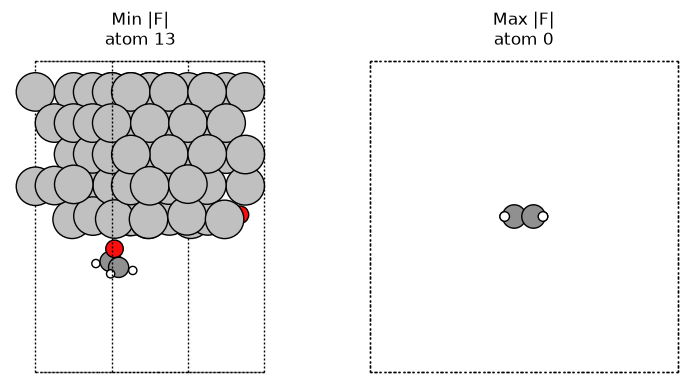


Fold 1
  Min |F| = 0.000 at structure 90, atom 29
  Max |F| = 1.556 at structure 5, atom 1


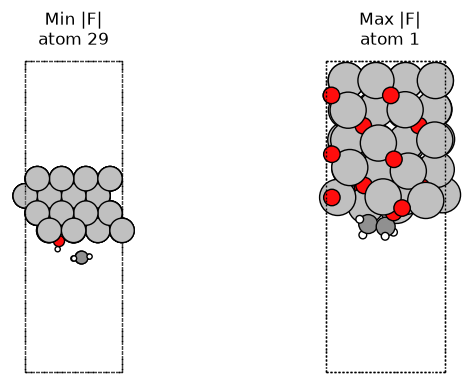


Fold 2
  Min |F| = 0.000 at structure 87, atom 29
  Max |F| = 5.068 at structure 104, atom 0


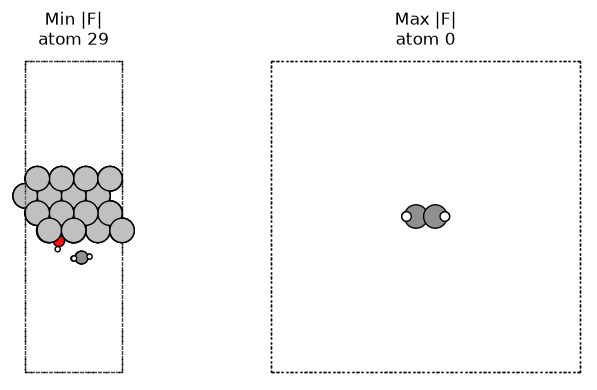


Fold 3
  Min |F| = 0.000 at structure 82, atom 29
  Max |F| = 5.068 at structure 98, atom 0


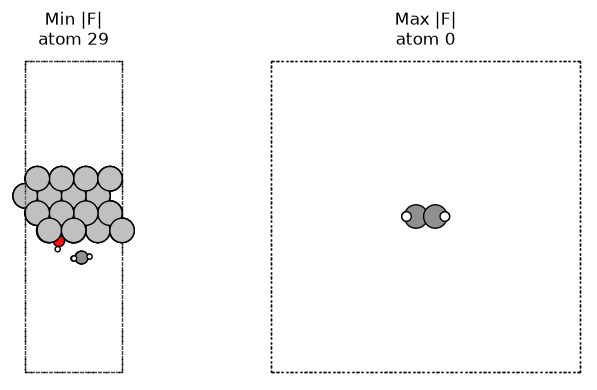

In [ ]:
# print 2D structures associated with each extreme

from ase.visualize.plot import plot_atoms
import matplotlib.pyplot as plt

for i in range(4):
    fold = read(f"../../training-data/folds/fold{i}_train.xyz", ":")

    min_mag = np.inf
    max_mag = -np.inf
    min_info = None
    max_info = None

    for struct_idx, atoms in enumerate(fold):
        mags = np.linalg.norm(atoms.get_forces(), axis=1)

        atom_min = np.argmin(mags)
        atom_max = np.argmax(mags)

        if mags[atom_min] < min_mag:
            min_mag = mags[atom_min]
            min_info = (struct_idx, atom_min)

        if mags[atom_max] > max_mag:
            max_mag = mags[atom_max]
            max_info = (struct_idx, atom_max)

    print(f"\nFold {i}")
    print(f"  Min |F| = {min_mag:.3f} at structure {min_info[0]}, atom {min_info[1]}")
    print(f"  Max |F| = {max_mag:.3f} at structure {max_info[0]}, atom {max_info[1]}")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    plot_atoms(fold[min_info[0]], axes[0], rotation="90x,0y,0z")
    axes[0].set_title(f"Min |F|\natom {min_info[1]}")

    plot_atoms(fold[max_info[0]], axes[1], rotation="90x,0y,0z")
    axes[1].set_title(f"Max |F|\natom {max_info[1]}")

    plt.tight_layout()
    plt.show()